**Bubble Sort**

In [19]:
def bubble_sort(arr):
    n = len(arr)
    i = 0
    for _ in range(n):
        for i in range(n - 1):
            # print(f"current ele = {arr[i]} next ele = {arr[i + 1]}")
            if(arr[i] > arr[i + 1]):
                arr[i], arr[i + 1] = arr[i + 1], arr[i]
            # print(arr)
    return arr

In [20]:
arr = [5,3,6,3,9,7,1,7,0]

In [21]:
bubble_sort(arr)

[0, 1, 3, 3, 5, 6, 7, 7, 9]

*Time Complexity* - O(n^2)  
*Space Complexity* - O(n)  
The inefficiency in bubble sort comes from the fact that we're shifting elements by at most one position at a time.  

# Divide and Conquer

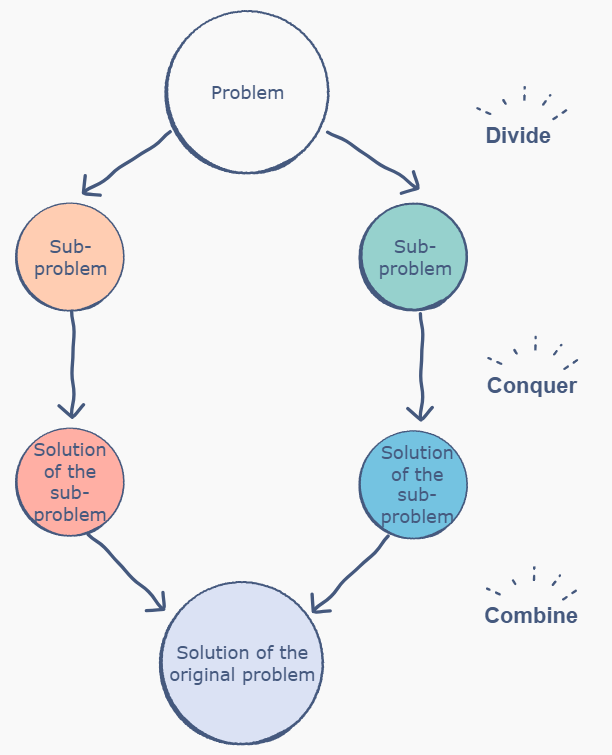

**Merge Sort**

In [4]:
def merge(left, right):
    merged = []
    i, j = 0, 0
    while (i < len(left) and j < len(right)):
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        elif right[j] < left[i]:
            merged.append(right[j])
            j += 1

    left_remaining = left[i:]
    right_remaining = right[j:]

    return merged + left_remaining + right_remaining
            
def merge_sort(arr):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2

    left = arr[:mid]
    right = arr[mid:]

    left_sorted, right_sorted = merge_sort(left), merge_sort(right)
    sorted_array = merge(left_sorted, right_sorted)

    return sorted_array

In [5]:
test_cases = []

# 1. (Empty List) - Edge Case
test_cases.append({
    "input": [],
    "output": []
})

# 2. (Single Element) - Edge Case
test_cases.append({
    "input": [5],
    "output": [5]
})

# 3. (Already Sorted) - Normal/Edge Case
test_cases.append({
    "input": [1, 2, 3, 4, 5],
    "output": [1, 2, 3, 4, 5]
})

# 4.(Reverse Sorted) - Normal Case
test_cases.append({
    "input": [10, 8, 6, 4, 2],
    "output": [2, 4, 6, 8, 10]
})

# 5. (Duplicate Elements) - Edge Case
test_cases.append({
    "input": [4, 2, 4, 1, 2],
    "output": [1, 2, 2, 4, 4]
})

# 6. (Negative Numbers) - Normal Case
test_cases.append({
    "input": [3, -1, 0, -5, 2],
    "output": [-5, -1, 0, 2, 3]
})

# 7.(All Elements Same) - Edge Case
test_cases.append({
    "input": [7, 7, 7, 7],
    "output": [7, 7, 7, 7]
})

# 8.(Large Random List) - Performance Test
import random
large_input = random.sample(range(1, 1000), 100)
test_cases.append({
    "input": large_input,
    "output": sorted(large_input)
})

In [6]:
for i in test_cases:
    res = merge_sort(i["input"])
    print(res)
    print(f"output = {i["output"]} - {res == i["output"]}")

[]
output = [] - True
[5]
output = [5] - True
[1, 2, 3, 4, 5]
output = [1, 2, 3, 4, 5] - True
[2, 4, 6, 8, 10]
output = [2, 4, 6, 8, 10] - True
[1, 2, 2, 4, 4]
output = [1, 2, 2, 4, 4] - True
[-5, -1, 0, 2, 3]
output = [-5, -1, 0, 2, 3] - True
[7, 7, 7, 7]
output = [7, 7, 7, 7] - True
[10, 20, 23, 25, 39, 41, 50, 67, 71, 79, 88, 91, 113, 117, 119, 123, 128, 132, 140, 142, 152, 153, 156, 157, 158, 176, 181, 220, 237, 249, 255, 271, 274, 280, 284, 299, 311, 323, 333, 365, 370, 374, 402, 403, 404, 412, 414, 418, 429, 430, 455, 461, 462, 473, 476, 477, 507, 508, 517, 526, 542, 554, 564, 565, 578, 603, 612, 640, 647, 670, 680, 686, 687, 694, 709, 715, 721, 726, 738, 758, 767, 780, 796, 822, 828, 835, 861, 883, 898, 901, 917, 918, 924, 929, 947, 950, 958, 968, 972, 975]
output = [10, 20, 23, 25, 39, 41, 50, 67, 71, 79, 88, 91, 113, 117, 119, 123, 128, 132, 140, 142, 152, 153, 156, 157, 158, 176, 181, 220, 237, 249, 255, 271, 274, 280, 284, 299, 311, 323, 333, 365, 370, 374, 402, 403, 404, 41

*Time complexity* - O(nlogn)  
*Space complexity* - O(n)

**Quick Sort**

1. If the list is empty or has just one element, return it. It's already sorted.  
2. Pick a random element from the list. This element is called a *pivot*.  
3. Reorder the list so that all elements with values less than or equal to the pivot come before the pivot, while all elements with values greater than the pivot come after it. This operation is called *partitioning*.  
4. The pivot element divides the array into two parts which can be sorted independently by making a recursive call to quicksort.  

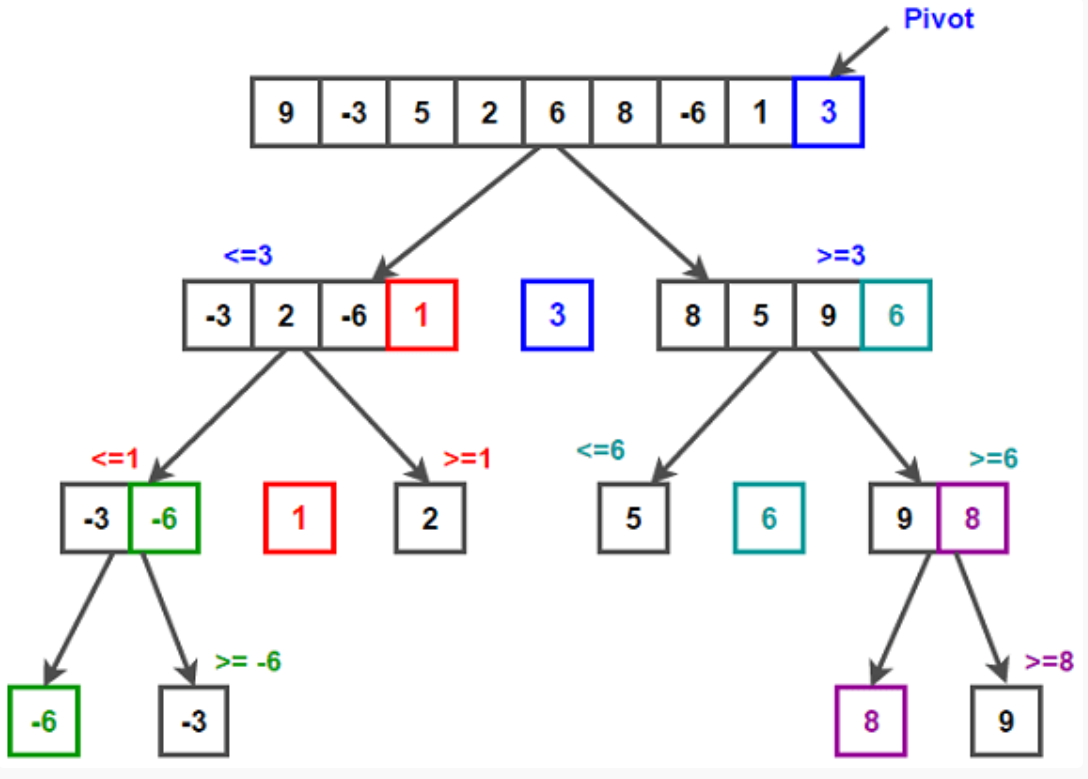

In [2]:
def partition(arr, start, end):
    if end is None:
        end = len(arr) - 1
        
    l, r = start, end - 1
    while r > l:
        if arr[l] <= arr[end]:
            l += 1
        elif arr[r] >= arr[end]:
            r -= 1
        else:
            arr[l], arr[r] = arr[r], arr[l]

    if(arr[l] > arr[end]):
        arr[l], arr[end] = arr[end], arr[l]
        return l
    else:
        return end
        
def quick_sort(arr, start = 0, end = None):
    if end is None:
        arr = list(arr)
        end = len(arr) - 1

    if start < end:
        pivot = partition(arr, start, end)
        quick_sort(arr, start, pivot - 1)
        quick_sort(arr, pivot + 1, end)

    return arr

In [3]:
for i in test_cases:
    res = quick_sort(i["input"])
    print(res)
    print(f"output = {i["output"]} - {res == i["output"]}")

[]
output = [] - True
[5]
output = [5] - True
[1, 2, 3, 4, 5]
output = [1, 2, 3, 4, 5] - True
[2, 4, 6, 8, 10]
output = [2, 4, 6, 8, 10] - True
[1, 2, 2, 4, 4]
output = [1, 2, 2, 4, 4] - True
[-5, -1, 0, 2, 3]
output = [-5, -1, 0, 2, 3] - True
[7, 7, 7, 7]
output = [7, 7, 7, 7] - True
[13, 51, 52, 56, 70, 84, 98, 115, 116, 117, 120, 138, 140, 146, 164, 179, 190, 196, 247, 255, 260, 268, 269, 277, 283, 289, 308, 315, 324, 331, 336, 350, 358, 369, 381, 385, 391, 397, 407, 428, 444, 448, 456, 464, 468, 484, 486, 487, 492, 493, 495, 504, 580, 589, 609, 617, 619, 621, 671, 673, 674, 679, 693, 700, 705, 721, 728, 759, 774, 785, 790, 792, 800, 803, 806, 813, 829, 832, 836, 838, 845, 848, 853, 855, 873, 881, 886, 896, 908, 916, 923, 937, 948, 956, 961, 965, 986, 989, 998, 999]
output = [13, 51, 52, 56, 70, 84, 98, 115, 116, 117, 120, 138, 140, 146, 164, 179, 190, 196, 247, 255, 260, 268, 269, 277, 283, 289, 308, 315, 324, 331, 336, 350, 358, 369, 381, 385, 391, 397, 407, 428, 444, 448, 456, 46

*Time complexity* - O(nlogn)  
*Space complexity*  
- additional space = O(1)  
- including input space = O(n)  